# 1.0 Analisis

## 1.1 Importacion de librerias y descarga

In [48]:
!pip install shap

In [49]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

## 1.2 carga de datos

In [50]:
df_gastos_persona = pd.read_csv('conjunto_de_datos_gastospersona_enigh2024_ns.csv')
df_ingresos_xintegrante = pd.read_csv('conjunto_de_datos_ingresos_enigh2024_ns.csv')
df_caracteristicas_hogar = pd.read_csv('conjunto_de_datos_concentradohogar_enigh2024_ns.csv')

## 1.2 Exploracion de datos

In [51]:
#caracteristicas
df_caracteristicas_hogar.info()
tamaño = df_caracteristicas_hogar.shape
print('tamaño: ' + str(tamaño))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91414 entries, 0 to 91413
Columns: 126 entries, folioviv to smg
dtypes: float64(104), int64(22)
memory usage: 87.9 MB
tamaño: (91414, 126)


In [52]:
# Comportamiento general de la data
df_caracteristicas_hogar.describe()

,folioviv,foliohog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,clase_hog,sexo_jefe,...,mater_serv,material,servicio,deposito,prest_terc,pago_tarje,deudas,balance,otras_erog,smg
count,9.141400e+04,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,...,91414.000000,91414.000000,91414.000000,9.141400e+04,91414.000000,91414.000000,91414.000000,91414.000000,9.141400e+04,9.141400e+04
mean,1.615952e+09,1.013641,15911.919148,2.526965,2.167830,320.454876,5419.840221,424.773339,2.121787,1.323386,...,437.440290,272.002960,165.437329,5.083510e+03,138.201119,1268.418394,480.077062,441.249934,3.913704e+02,2.240370e+04
std,9.321405e+08,0.131718,9315.008029,1.335543,0.856087,201.082093,3032.579567,474.677171,0.643906,0.467771,...,5227.735138,3871.717469,2080.656565,2.793275e+04,1866.005384,7951.381442,3258.076472,5003.416681,7.937269e+03,3.297482e-08
min,1.000019e+08,1.000000,1001.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
25%,8.028396e+08,1.000000,8019.000000,1.000000,2.000000,148.000000,2839.000000,141.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
50%,1.565433e+09,1.000000,15121.500000,3.000000,2.000000,308.000000,5433.000000,288.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
75%,2.408016e+09,1.000000,24028.000000,4.000000,3.000000,492.000000,8015.750000,526.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,2.950810e+03,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
max,3.260594e+09,4.000000,32056.000000,4.000000,4.000000,681.000000,10593.000000,7127.000000,5.000000,2.000000,...,989010.980000,870329.670000,185869.560000,4.677049e+06,244844.260000,543442.620000,293478.260000,751585.570000,1.076087e+06,2.240370e+04


In [53]:
#lista de Columnas
df_caracteristicas_hogar.columns.tolist()

['folioviv',
 'foliohog',
 'ubica_geo',
 'tam_loc',
 'est_socio',
 'est_dis',
 'upm',
 'factor',
 'clase_hog',
 'sexo_jefe',
 'edad_jefe',
 'educa_jefe',
 'tot_integ',
 'hombres',
 'mujeres',
 'mayores',
 'menores',
 'p12_64',
 'p65mas',
 'ocupados',
 'percep_ing',
 'perc_ocupa',
 'ing_cor',
 'ingtrab',
 'trabajo',
 'sueldos',
 'horas_extr',
 'comisiones',
 'aguinaldo',
 'indemtrab',
 'otra_rem',
 'remu_espec',
 'negocio',
 'noagrop',
 'industria',
 'comercio',
 'servicios',
 'agrope',
 'agricolas',
 'pecuarios',
 'reproducc',
 'pesca',
 'otros_trab',
 'rentas',
 'utilidad',
 'arrenda',
 'transfer',
 'jubilacion',
 'becas',
 'donativos',
 'remesas',
 'bene_gob',
 'transf_hog',
 'trans_inst',
 'estim_alqu',
 'otros_ing',
 'gasto_mon',
 'alimentos',
 'ali_dentro',
 'cereales',
 'carnes',
 'pescado',
 'leche',
 'huevo',
 'aceites',
 'tuberculo',
 'verduras',
 'frutas',
 'azucar',
 'cafe',
 'especias',
 'otros_alim',
 'bebidas',
 'ali_fuera',
 'tabaco',
 'vesti_calz',
 'vestido',
 'calzado

## 1.3 Seleccion de datos segun su relevancia

In [54]:
columns_carc_jefe = [
    'clase_hog', #tipo de hogar
    'sexo_jefe', #sexo
    'edad_jefe', #edad
    'educa_jefe', #nivel de educacion
    'menores'     #Probablemente hijos y nietos
    ]
columns_ingr_jefe= [
    "ing_cor",     # ingreso total
    "gasto_mon",   # gasto total
    "ingtrab",     # ingreso laboral
    "transfer",    # apoyos
    "negocio",      # ingreso independiente
    "becas"
    ]
columns = columns_carc_jefe + columns_ingr_jefe
#data seleccionada
df_model=df_caracteristicas_hogar[columns]
df_model.head()

,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas
0,2,1,32,6,2,138232.38,47478.66,130518.10,7714.28,0.0,0.0
1,2,1,48,9,0,118014.04,38782.74,103829.72,2571.42,0.0,0.0
2,2,2,60,6,0,46866.32,28601.26,45580.61,1285.71,0.0,0.0
3,2,1,43,8,0,110430.10,43509.83,97169.95,195.64,0.0,0.0
4,2,2,29,8,2,99494.12,132552.40,93687.67,0.00,0.0,0.0


## 1.3 Análisis descriptivo de las variables

Se realizó un análisis estadístico descriptivo sobre un conjunto de datos compuesto por 91,414 observaciones, con el objetivo de caracterizar la distribución de variables sociodemográficas y económicas relevantes.

En términos generales, la variable clase_hog presenta una media de 2.12 con una desviación estándar de 0.64, lo que sugiere una baja dispersión y una concentración predominante en categorías intermedias. De manera similar, sexo_jefe muestra una media de 1.32, indicando una mayor proporción de hogares encabezados por una categoría específica (probablemente masculina si se codifica binariamente), con baja variabilidad (σ = 0.47).

La variable edad_jefe presenta una media de 51.53 años (σ = 15.99), con valores que oscilan entre 14 y 106 años, lo que evidencia una amplia heterogeneidad etaria. Por su parte, el nivel educativo (educa_jefe) tiene una media de 5.88 (σ = 2.57), concentrándose entre los niveles 4 y 8 (percentiles 25 y 75), lo que sugiere una distribución relativamente centrada en niveles educativos medios.

Respecto a la composición del hogar, la variable menores presenta una media de 0.61 (σ = 0.91), indicando que la mayoría de los hogares tienen pocos o ningún menor, aunque existen casos extremos de hasta 9 menores.

En el ámbito económico, se observa una alta dispersión en los ingresos y gastos. El ingreso corriente (ing_cor) tiene una media de aproximadamente 72,273 unidades monetarias, con una desviación estándar considerable (σ ≈ 93,876), lo que indica una fuerte desigualdad. Esta tendencia se replica en gasto_mon (media ≈ 43,411) y ingtrab (media ≈ 47,446), ambas con alta variabilidad y presencia de valores extremos elevados.

Las variables de transferencias (transfer) y actividad de negocio (negocio) muestran distribuciones altamente sesgadas, con medianas cercanas a cero, lo que sugiere que una gran proporción de la población no recibe transferencias ni reporta ingresos por negocio, aunque existen valores máximos considerablemente altos que influyen en la media.

Finalmente, la variable becas presenta una media de 108.30 con una desviación estándar de 1,630.98, lo que indica una distribución fuertemente asimétrica, con la mayoría de los valores concentrados en cero y pocos casos con montos elevados.

En conjunto, los resultados evidencian asimetría positiva y presencia de outliers en variables económicas, así como baja variabilidad en variables categóricas, lo cual debe ser considerado en etapas posteriores de modelado, particularmente en la selección de técnicas robustas o transformaciones de variables.

In [55]:
df_model.describe()

,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas
count,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,9.141400e+04,9.141400e+04,9.141400e+04,9.141400e+04,9.141400e+04,91414.000000
mean,2.121787,1.323386,51.537281,5.884132,0.613331,7.227359e+04,4.341137e+04,4.744601e+04,1.325804e+04,6.028067e+03,108.303316
std,0.643906,0.467771,15.994928,2.575050,0.915634,9.387659e+04,3.869615e+04,5.185134e+04,2.860706e+04,2.208587e+04,1630.979532
min,1.000000,1.000000,14.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,1.000000,39.000000,4.000000,0.000000,3.452087e+04,2.152433e+04,1.458293e+04,0.000000e+00,0.000000e+00,0.000000
50%,2.000000,1.000000,51.000000,6.000000,0.000000,5.566618e+04,3.418251e+04,3.641086e+04,4.487450e+03,0.000000e+00,0.000000
75%,2.000000,2.000000,63.000000,8.000000,1.000000,8.884073e+04,5.304713e+04,6.500962e+04,1.651102e+04,1.475625e+03,0.000000
max,5.000000,2.000000,106.000000,11.000000,9.000000,1.743198e+07,1.635931e+06,2.347826e+06,3.200868e+06,2.188033e+06,177049.160000


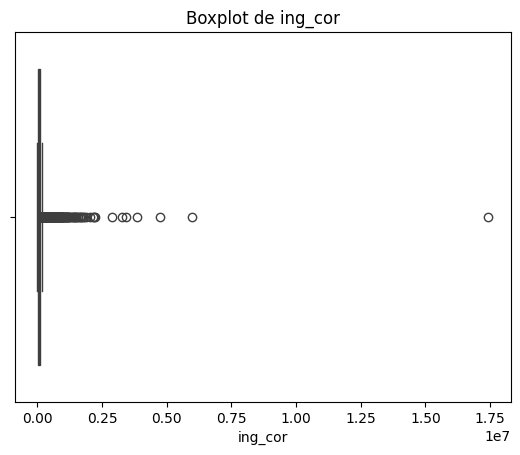

In [56]:
#Demostracion de sesgo en la variable "ing_cor"
sns.boxplot(x=df_model["ing_cor"])
plt.title("Boxplot de ing_cor")
plt.show()

## 1.4 Limpieza de datos

In [57]:
#Transformación logarítmica para outliers
for col in columns_ingr_jefe:
    df_model[col] = np.log1p(df_model[col])

/tmp/ipykernel_27090/2632885442.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = np.log1p(df_model[col])


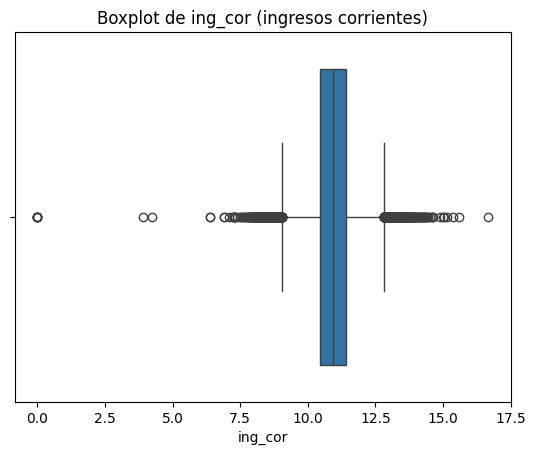

In [58]:
sns.boxplot(x=df_model["ing_cor"])
plt.title("Boxplot de ing_cor (ingresos corrientes)")
plt.show()

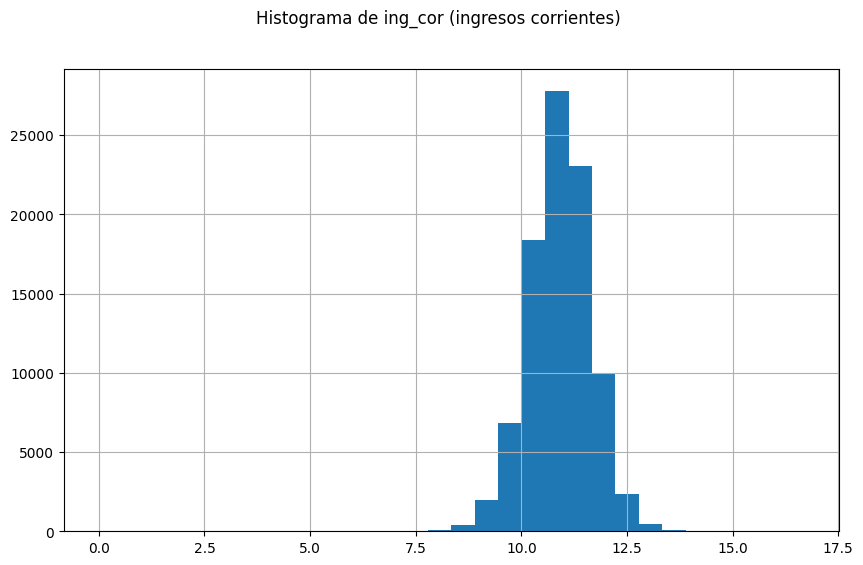

In [59]:
df_model['ing_cor'].hist(bins=30, figsize=(10,6))
plt.suptitle("Histograma de ing_cor (ingresos corrientes)")
plt.show()

Durante la etapa de preprocesamiento, se aplicaron técnicas orientadas a mejorar la calidad y distribución de las variables, particularmente aquellas de tipo económico, caracterizadas por alta dispersión y presencia de valores extremos.

Con el objetivo de mitigar el efecto de outliers y reducir la asimetría positiva en variables como ingresos y gastos, se implementó una transformación logarítmica utilizando la función
log
⁡
(
1
+
𝑥
)
log(1+x). Esta transformación permitió comprimir la escala de los valores elevados sin perder la información relativa entre observaciones.

La aplicación se realizó de manera iterativa sobre el conjunto de variables económicas (columns_ing_jefe), asegurando una transformación homogénea en todas ellas. Este procedimiento es común en análisis socioeconómicos, donde las distribuciones suelen ser altamente sesgadas.

In [60]:
df_model.describe()

,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas
count,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000
mean,2.121787,1.323386,51.537281,5.884132,0.613331,10.913652,10.407163,9.176288,6.339425,2.638833,0.210753
std,0.643906,0.467771,15.994928,2.575050,0.915634,0.738044,0.779184,3.607065,4.319474,4.190399,1.261686
min,1.000000,1.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,39.000000,4.000000,0.000000,10.449348,9.976986,9.587676,0.000000,0.000000,0.000000
50%,2.000000,1.000000,51.000000,6.000000,0.000000,10.927146,10.439499,10.502650,8.409263,0.000000,0.000000
75%,2.000000,2.000000,63.000000,8.000000,1.000000,11.394612,10.878955,11.082306,9.711844,7.297514,0.000000
max,5.000000,2.000000,106.000000,11.000000,9.000000,16.673817,14.307723,14.669001,14.978933,14.598514,12.084188


Se generó una nueva variable binaria denominada con_negocio, la cual indica la presencia de ingresos por actividad empresarial. Esta se construyó a partir de la variable original negocio, asignando el valor de 1 cuando el ingreso es mayor a cero y 0 en caso contrario.

Esta transformación permite simplificar la variable continua en una representación categórica, facilitando su uso en modelos de clasificación y análisis interpretativo.

In [61]:
df_model["con_negocio"] = (df_model["negocio"] > 0).astype(int)
df_model.head()

/tmp/ipykernel_27090/3905636569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["con_negocio"] = (df_model["negocio"] > 0).astype(int)


,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas,con_negocio
0,2,1,32,6,2,11.836699,10.768057,11.779275,8.950958,0.0,0.0,0
1,2,1,48,9,0,11.678567,10.565756,11.550517,7.852602,0.0,0.0,0
2,2,2,60,6,0,10.755076,10.261241,10.727260,7.159844,0.0,0.0,0
3,2,1,43,8,0,11.612147,10.680765,11.484227,5.281375,0.0,0.0,0
4,2,2,29,8,2,11.507864,11.794741,11.447733,0.000000,0.0,0.0,0


## 1.5 Partituracion de datos para entrenamiento y prueba

¿Se definió la variable objetivo (y) a partir de sexo_jefe, ajustando su codificación mediante la resta de 1, con el fin de transformarla a un formato binario estándar (0 y 1), requerido por modelos de clasificación como XGBoost.

In [62]:
y = df_model["sexo_jefe"] - 1
X = df_model.drop("sexo_jefe", axis=1)

El análisis de frecuencias de la variable sexo_jefe revela una distribución desbalanceada, donde la categoría 1 presenta una mayor proporción (61,852 casos) en comparación con la categoría 2 (29,562 casos).

Este hallazgo indica que la mayoría de los hogares están encabezados por un solo grupo (hombres), lo cual introduce un desbalance de clases en la variable objetivo.

Dicho desbalance es relevante para el modelado, ya que puede sesgar el desempeño del modelo hacia la clase mayoritaria, por lo que se recomienda considerar técnicas como ponderación de clases o métricas robustas (F1-score, recall) en la evaluación

In [63]:
print('Mucho mas hombres que mujeres')
df_model["sexo_jefe"].value_counts()

Mucho mas hombres que mujeres


,count
sexo_jefe,
1,61852
2,29562


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 1.6 Matriz de corelacion de variables

In [65]:
corr = df_model.corr()
print(corr)

             clase_hog  sexo_jefe  edad_jefe  educa_jefe   menores   ing_cor  \
clase_hog     1.000000   0.016225   0.021987   -0.065560  0.277552  0.251055   
sexo_jefe     0.016225   1.000000   0.084600   -0.050710 -0.057627 -0.066794   
edad_jefe     0.021987   0.084600   1.000000   -0.403845 -0.364719 -0.059202   
educa_jefe   -0.065560  -0.050710  -0.403845    1.000000  0.032052  0.406754   
menores       0.277552  -0.057627  -0.364719    0.032052  1.000000  0.023474   
ing_cor       0.251055  -0.066794  -0.059202    0.406754  0.023474  1.000000   
gasto_mon     0.237393  -0.088498  -0.178048    0.432768  0.093857  0.684908   
ingtrab       0.262210  -0.137630  -0.374607    0.193443  0.169436  0.364826   
transfer      0.082107   0.159602   0.372411   -0.170220 -0.040525 -0.027127   
negocio       0.096655  -0.090198   0.038295   -0.115317  0.047906 -0.058436   
becas         0.055537  -0.007437  -0.058961    0.035051  0.109220  0.039298   
con_negocio   0.096525  -0.084352   0.05

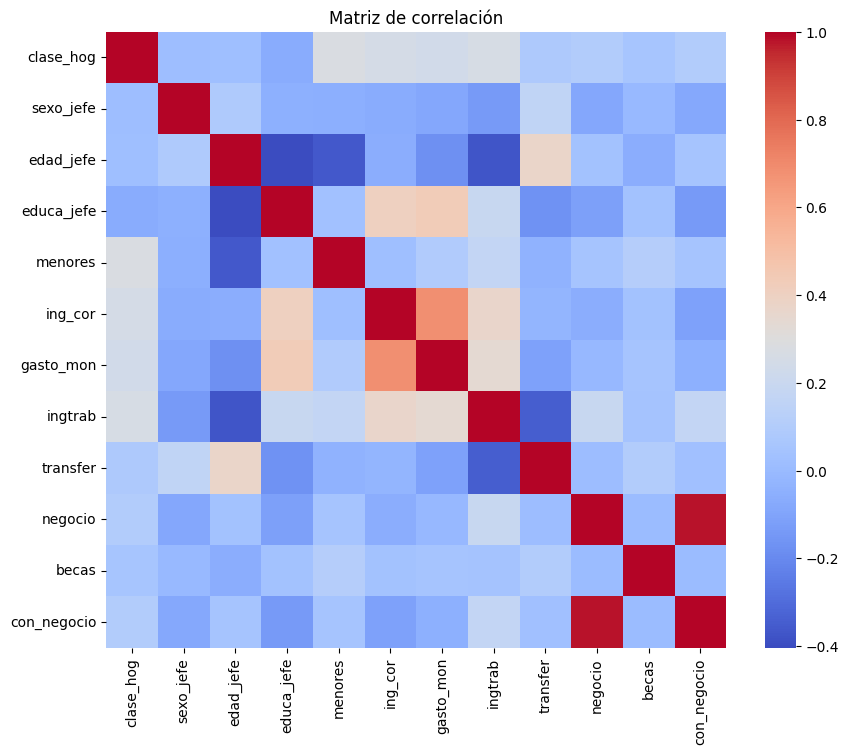

In [66]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Matriz de correlación")
plt.show()

Con el objetivo de abordar el desbalance de clases en la variable objetivo (sexo_jefe), se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) sobre el conjunto de entrenamiento.

Este método genera nuevas muestras sintéticas de la clase minoritaria a partir de interpolaciones entre observaciones existentes, permitiendo equilibrar la distribución sin duplicar datos.

Como resultado, ambas clases quedaron perfectamente balanceadas (49,481 observaciones cada una), lo que contribuye a:

Reducir el sesgo del modelo hacia la clase mayoritaria
Mejorar la capacidad de generalización
Obtener métricas de evaluación más representativas

Este paso es fundamental para garantizar un entrenamiento más justo y robusto en modelos de clasificación.

In [67]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [68]:
pd.Series(y_train_res).value_counts()

,count
sexo_jefe,
0,49481
1,49481


## 1.7 Entrenamiento de modelos





Los modelos de clasificación entrenados alcanzaron un desempeño moderado, con valores de accuracy cercanos a 0.67, destacando XGBoost y Random Forest como los enfoques más efectivos. A pesar de la aplicación de técnicas de balanceo como SMOTE, se observó una menor capacidad predictiva en la clase minoritaria, lo que sugiere una limitada separabilidad entre los grupos.

No obstante, el hecho de que el modelo logre predecir el sexo del jefe del hogar a partir de variables económicas indica la existencia de patrones diferenciados entre hombres y mujeres. Estos resultados son consistentes con la presencia de una posible brecha económica o laboral, reflejada en diferencias en ingresos, gastos y otras fuentes económicas.

Sin embargo, es importante destacar que estos hallazgos no implican causalidad directa, sino que evidencian correlaciones presentes en los datos.

In [69]:
model_Random_forest = RandomForestClassifier(random_state=42)

model_Random_forest.fit(X_train_res, y_train_res)
y_pred = model_Random_forest.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6712793305256249
              precision    recall  f1-score   support

           0       0.76      0.75      0.75     12371
           1       0.49      0.51      0.50      5912

    accuracy                           0.67     18283
   macro avg       0.63      0.63      0.63     18283
weighted avg       0.68      0.67      0.67     18283



In [70]:
model_XGB = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

model_XGB.fit(X_train_res, y_train_res)

y_pred = model_XGB.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6661926379696986
              precision    recall  f1-score   support

           0       0.78      0.70      0.74     12371
           1       0.49      0.59      0.53      5912

    accuracy                           0.67     18283
   macro avg       0.63      0.65      0.64     18283
weighted avg       0.69      0.67      0.67     18283



In [76]:
model_logistic = LogisticRegression(max_iter=1000)

model_logistic.fit(X_train_res, y_train_res)
y_pred = model_logistic.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5826724279385221
              precision    recall  f1-score   support

           0       0.75      0.57      0.65     12371
           1       0.40      0.60      0.48      5912

    accuracy                           0.58     18283
   macro avg       0.58      0.59      0.57     18283
weighted avg       0.64      0.58      0.60     18283



In [77]:
model_red_MLP = MLPClassifier(max_iter=500)

model_red_MLP.fit(X_train_res, y_train_res)
y_pred = model_red_MLP.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6624733358857956
              precision    recall  f1-score   support

           0       0.79      0.69      0.73     12371
           1       0.48      0.61      0.54      5912

    accuracy                           0.66     18283
   macro avg       0.63      0.65      0.64     18283
weighted avg       0.69      0.66      0.67     18283



## 1.8 Resultado de los modelos

Los modelos de clasificación entrenados alcanzaron un desempeño moderado, con valores de accuracy cercanos a 0.67, destacando XGBoost y Random Forest como los enfoques más efectivos. A pesar de la aplicación de técnicas de balanceo como SMOTE, se observó una menor capacidad predictiva en la clase minoritaria, lo que sugiere una limitada separabilidad entre los grupos.

No obstante, el hecho de que el modelo logre predecir el sexo del jefe del hogar a partir de variables económicas indica la existencia de patrones diferenciados entre hombres y mujeres. Estos resultados son consistentes con la presencia de una posible brecha económica o laboral, reflejada en diferencias en ingresos, gastos y otras fuentes económicas.

Sin embargo, es importante destacar que estos hallazgos no implican causalidad directa, sino que evidencian correlaciones presentes en los datos.

## 1.9 Interpretacion del modelo

### 1.9.1 Importancia de variables en Random Forest

Con el objetivo de complementar el análisis de interpretabilidad, se evaluó la importancia de las variables utilizando el modelo Random Forest, a partir de la métrica interna feature importance, la cual estima la contribución relativa de cada variable en la reducción de la impureza durante el proceso de entrenamiento.

Los resultados indican que las variables con mayor relevancia son gasto_mon (0.170), ing_cor (0.166), transfer (0.166) e ingtrab (0.157), seguidas por edad_jefe (0.146). Este conjunto de variables concentra la mayor parte del poder predictivo del modelo, destacando el predominio de factores económicos.

En particular, el hecho de que gastos, ingresos y transferencias ocupen las primeras posiciones sugiere que el modelo identifica patrones asociados a la capacidad económica y flujo de recursos como principales elementos diferenciadores en la clasificación. Esto refuerza la evidencia observada previamente con SHAP, donde estas mismas variables mostraban un alto impacto en la predicción.

Por otro lado, variables como educa_jefe, negocio y clase_hog presentan una importancia moderada, lo que indica que, si bien contribuyen al modelo, su capacidad discriminativa es menor en comparación con las variables económicas principales.

Finalmente, variables como menores y becas muestran una baja relevancia, lo cual puede atribuirse a su menor variabilidad o a su limitada relación directa con la variable objetivo dentro del contexto del modelo.

En conjunto, estos resultados confirman que:

El modelo está fuertemente influenciado por variables económicas (ingresos y gastos)
Existe una estructura consistente en la importancia de variables entre diferentes métodos (Random Forest y SHAP)
Las diferencias en condiciones económicas son determinantes en la predicción

Desde una perspectiva interpretativa, estos hallazgos respaldan la hipótesis de que existen patrones económicos diferenciados entre grupos, lo cual es consistente con la presencia de una posible brecha económica o laboral. No obstante, al igual que en análisis previos, estos resultados deben interpretarse como evidencia de asociación y no de causalidad directa.

In [72]:
importancias = pd.Series(
    model_Random_forest.feature_importances_,
    index=X_train.columns
)

print(importancias.sort_values(ascending=False).head(10))

gasto_mon     0.170485
ing_cor       0.166366
transfer      0.165621
ingtrab       0.157324
edad_jefe     0.146531
educa_jefe    0.066689
negocio       0.046745
clase_hog     0.038370
menores       0.027170
becas         0.008562
dtype: float64


### 1.9.2 Interpretabilidad del modelo mediante SHAP

Con el objetivo de comprender el comportamiento del modelo y la contribución de cada variable en la predicción, se empleó el método de interpretabilidad SHAP (SHapley Additive exPlanations) sobre el modelo XGBoost entrenado. Este enfoque permite cuantificar el impacto individual de cada característica en la salida del modelo, proporcionando una interpretación tanto global como local.

El análisis del gráfico resumen revela que las variables con mayor influencia en la predicción son transfer, edad_jefe y clase_hog, seguidas por variables económicas clave como ingtrab (ingreso laboral) e ing_cor (ingreso corriente). La posición de estas variables en la gráfica indica que son las que generan mayores cambios en la probabilidad de clasificación, lo que sugiere que el modelo basa sus decisiones principalmente en factores económicos y sociodemográficos.

En términos de comportamiento, se observa que los valores altos (representados en rojo) en variables como transferencias e ingresos tienden a desplazar la predicción hacia un lado específico del modelo, mientras que valores bajos (en azul) generan el efecto contrario. Esta distribución no es aleatoria, sino que muestra una separación consistente, lo que indica que existen patrones diferenciados en la estructura económica de los individuos.

Particularmente relevante es el papel de las variables económicas (ingtrab, ing_cor, transfer), ya que su alta contribución sugiere que las diferencias en ingresos y apoyos económicos son determinantes en la clasificación del sexo del jefe del hogar. Esto implica que el modelo está capturando estructuras económicas subyacentes, más allá de simples correlaciones superficiales.

Asimismo, variables como menores y educa_jefe presentan una influencia moderada, lo que indica que factores relacionados con la composición del hogar y el nivel educativo también participan en la diferenciación, aunque en menor medida.

Por otro lado, variables como becas y negocio muestran una contribución limitada, lo cual puede explicarse por su alta concentración en valores cero, reduciendo su capacidad discriminativa dentro del modelo.

En conjunto, los resultados del análisis SHAP permiten concluir que:

El modelo se apoya principalmente en variables económicas para realizar la clasificación
Existen patrones sistemáticos en la distribución de ingresos y transferencias
La predicción del sexo del jefe del hogar no es aleatoria, sino que responde a diferencias estructurales en los datos

Estos hallazgos son consistentes con la presencia de una posible brecha económica o laboral, en la cual hombres y mujeres presentan condiciones diferenciadas en términos de ingresos y participación económica. No obstante, es importante señalar que, aunque el modelo identifica patrones claros, estos resultados no implican causalidad directa, sino asociaciones presentes en los datos.

Finalmente, el uso de SHAP no solo permite validar el desempeño del modelo, sino también aportar interpretabilidad y transparencia, aspectos fundamentales en aplicaciones con impacto social, donde la comprensión de los factores subyacentes es tan relevante como la precisión del modelo.

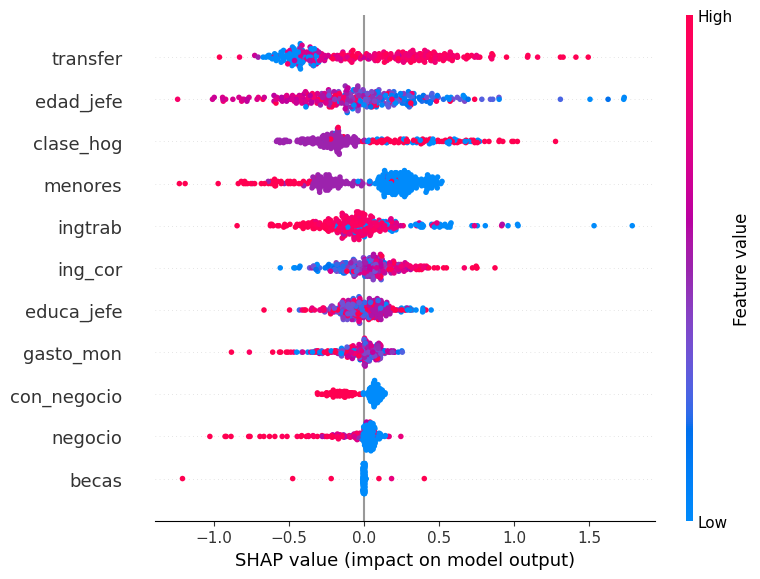

In [73]:
X_sample = X_test.sample(300, random_state=42)

explainer = shap.TreeExplainer(model_XGB)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

## 1.10 Análisis comparativo de ingresos por sexo del jefe del hogar (plus)

Con el objetivo de explorar posibles diferencias económicas entre grupos, se realizó un análisis visual mediante diagramas de caja (boxplot) de la variable ing_cor (ingreso corriente) en función de sexo_jefe.

Los resultados muestran que ambas distribuciones presentan una forma similar, con medianas cercanas y rangos intercuartílicos comparables, lo que sugiere que, a nivel general, los ingresos no difieren drásticamente entre ambos grupos. Sin embargo, se observan diferencias sutiles en la dispersión y en la presencia de valores extremos.

En particular, uno de los grupos presenta una ligera mayor concentración de valores altos y una mayor variabilidad, lo que podría indicar una mayor heterogeneidad en los niveles de ingreso. Asimismo, la presencia de múltiples outliers en ambos casos refleja la naturaleza altamente sesgada de las variables económicas.

Aunque las diferencias visuales no son extremadamente marcadas, este análisis sugiere que sí existen variaciones en la distribución de ingresos entre los grupos, las cuales podrían estar siendo capturadas por los modelos de aprendizaje automático.

Estos hallazgos, en conjunto con los resultados de los modelos predictivos y el análisis de importancia de variables, refuerzan la idea de que las variables económicas contienen información relevante para diferenciar entre grupos, lo cual es consistente con la posible existencia de una brecha económica.

No obstante, se recomienda complementar este análisis con pruebas estadísticas formales para determinar si las diferencias observadas son estadísticamente significativas.

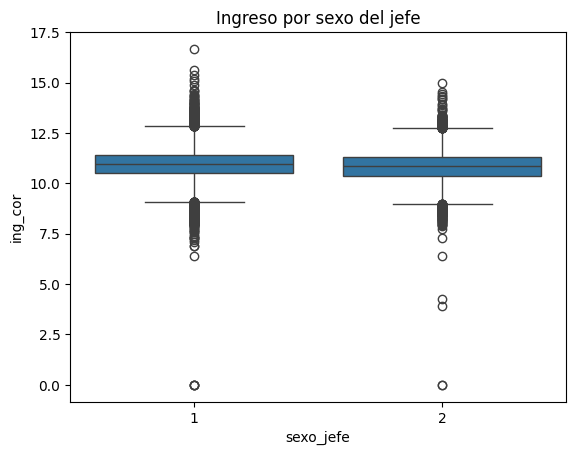

In [75]:
sns.boxplot(x="sexo_jefe", y="ing_cor", data=df_model)

plt.title("Ingreso por sexo del jefe")
plt.show()

# Fuentes
[Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH) ](https://www.inegi.org.mx/programas/enigh/nc/2024/#datos_abiertos)